In [1]:

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set(style="whitegrid")
np.random.seed(42)



In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# Create a DataFrame with feature names
df = pd.DataFrame(abalone.data.features, columns=abalone.data.feature_names)


# Create a DataFrame with feature names
df = pd.DataFrame(abalone.data.features, columns=abalone.data.feature_names)

# Add target values (which are the target labels)
df["target"] = abalone.data.targets

"""
BE CAREFUL:
We use a classification dataset stored in scikit-learn, but you can use any dataset you want (e.g., from a CSV file).
In that case, you will need to load the dataset using pandas (e.g., pd.read_csv) and preprocess it accordingly (e.g., handle missing values, encode categorical variables, etc.).
For simplicity, we are using the Iris dataset, which is clean and ready for classification tasks.
"""


print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (4177, 9)
Columns: ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'target']


The dataset contains 4177 samples with 9 columns: 4 features (sepal length, sepal width, petal length, petal width) and 1 target variable (species).


In [22]:
# Display the first few rows of the DataFrame 
# (by default, it shows the first 5 rows, but you can specify the number of rows to display by passing an argument to head(), e.g., df.head(10) to show the first 10 rows)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,target
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [23]:
# Display information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   target          4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [24]:
# Display summary statistics of the DataFrame
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,target
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [15]:
print("Keys of abalone dataset: \n{}".format(abalone.keys()))

Keys of abalone dataset: 
dict_keys(['data', 'metadata', 'variables'])


In [16]:
print("Target column: {}".format(abalone.data.targets.columns.tolist()))
print("Target values range: {} to {}".format(abalone.data.targets.values.min(), abalone.data.targets.values.max()))

Target column: ['Rings']
Target values range: 1 to 29


In [17]:
print("Type of data: {}".format(type(abalone.data['features'])))

Type of data: <class 'pandas.DataFrame'>


In [18]:
print("Shape of features: {}".format(abalone.data['features'].shape))

Shape of features: (4177, 8)


In [19]:
print("First five lignes of data:\n{}".format(abalone.data['features'].iloc[:5]))

First five lignes of data:
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  
0         0.150  
1         0.070  
2         0.210  
3         0.155  
4         0.055  


In [8]:
print("Type of target: {}".format(type(abalone.data['targets'].values)))

Type of target: <class 'numpy.ndarray'>


Target is a one-dimensional array, with one entry per abalone

In [9]:
print("Shape of target: {}".format(abalone.data['targets'].shape))

Shape of target: (4177, 1)


In [10]:
print("Target:\n{}".format(abalone.data['targets']))

Target:
      Rings
0        15
1         7
2         9
3        10
4         7
...     ...
4172     11
4173     10
4174      9
4175     10
4176     12

[4177 rows x 1 columns]


### Training and Testing Data

In [11]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    abalone.data['features'], abalone.data['targets'], random_state=0)

In [12]:
print("X_train shape: {}".format(X_train.shape)) 
print("y_train shape: {}".format(y_train.shape))

X_train shape: (3132, 8)
y_train shape: (3132, 1)


In [13]:
print("X_test shape: {}".format(X_test.shape)) 
print("y_test shape: {}".format(y_test.shape))

X_test shape: (1045, 8)
y_test shape: (1045, 1)


## 3) Visualization (Guided)
We now visualize the data to understand how the classes separate.

- **Pairplot** shows pairwise relationships.
- **Histograms** show distributions per feature.
- **Scatter plot** highlights two features.

Text(0.5, 0.98, 'Pairwise Relationships Between Features')

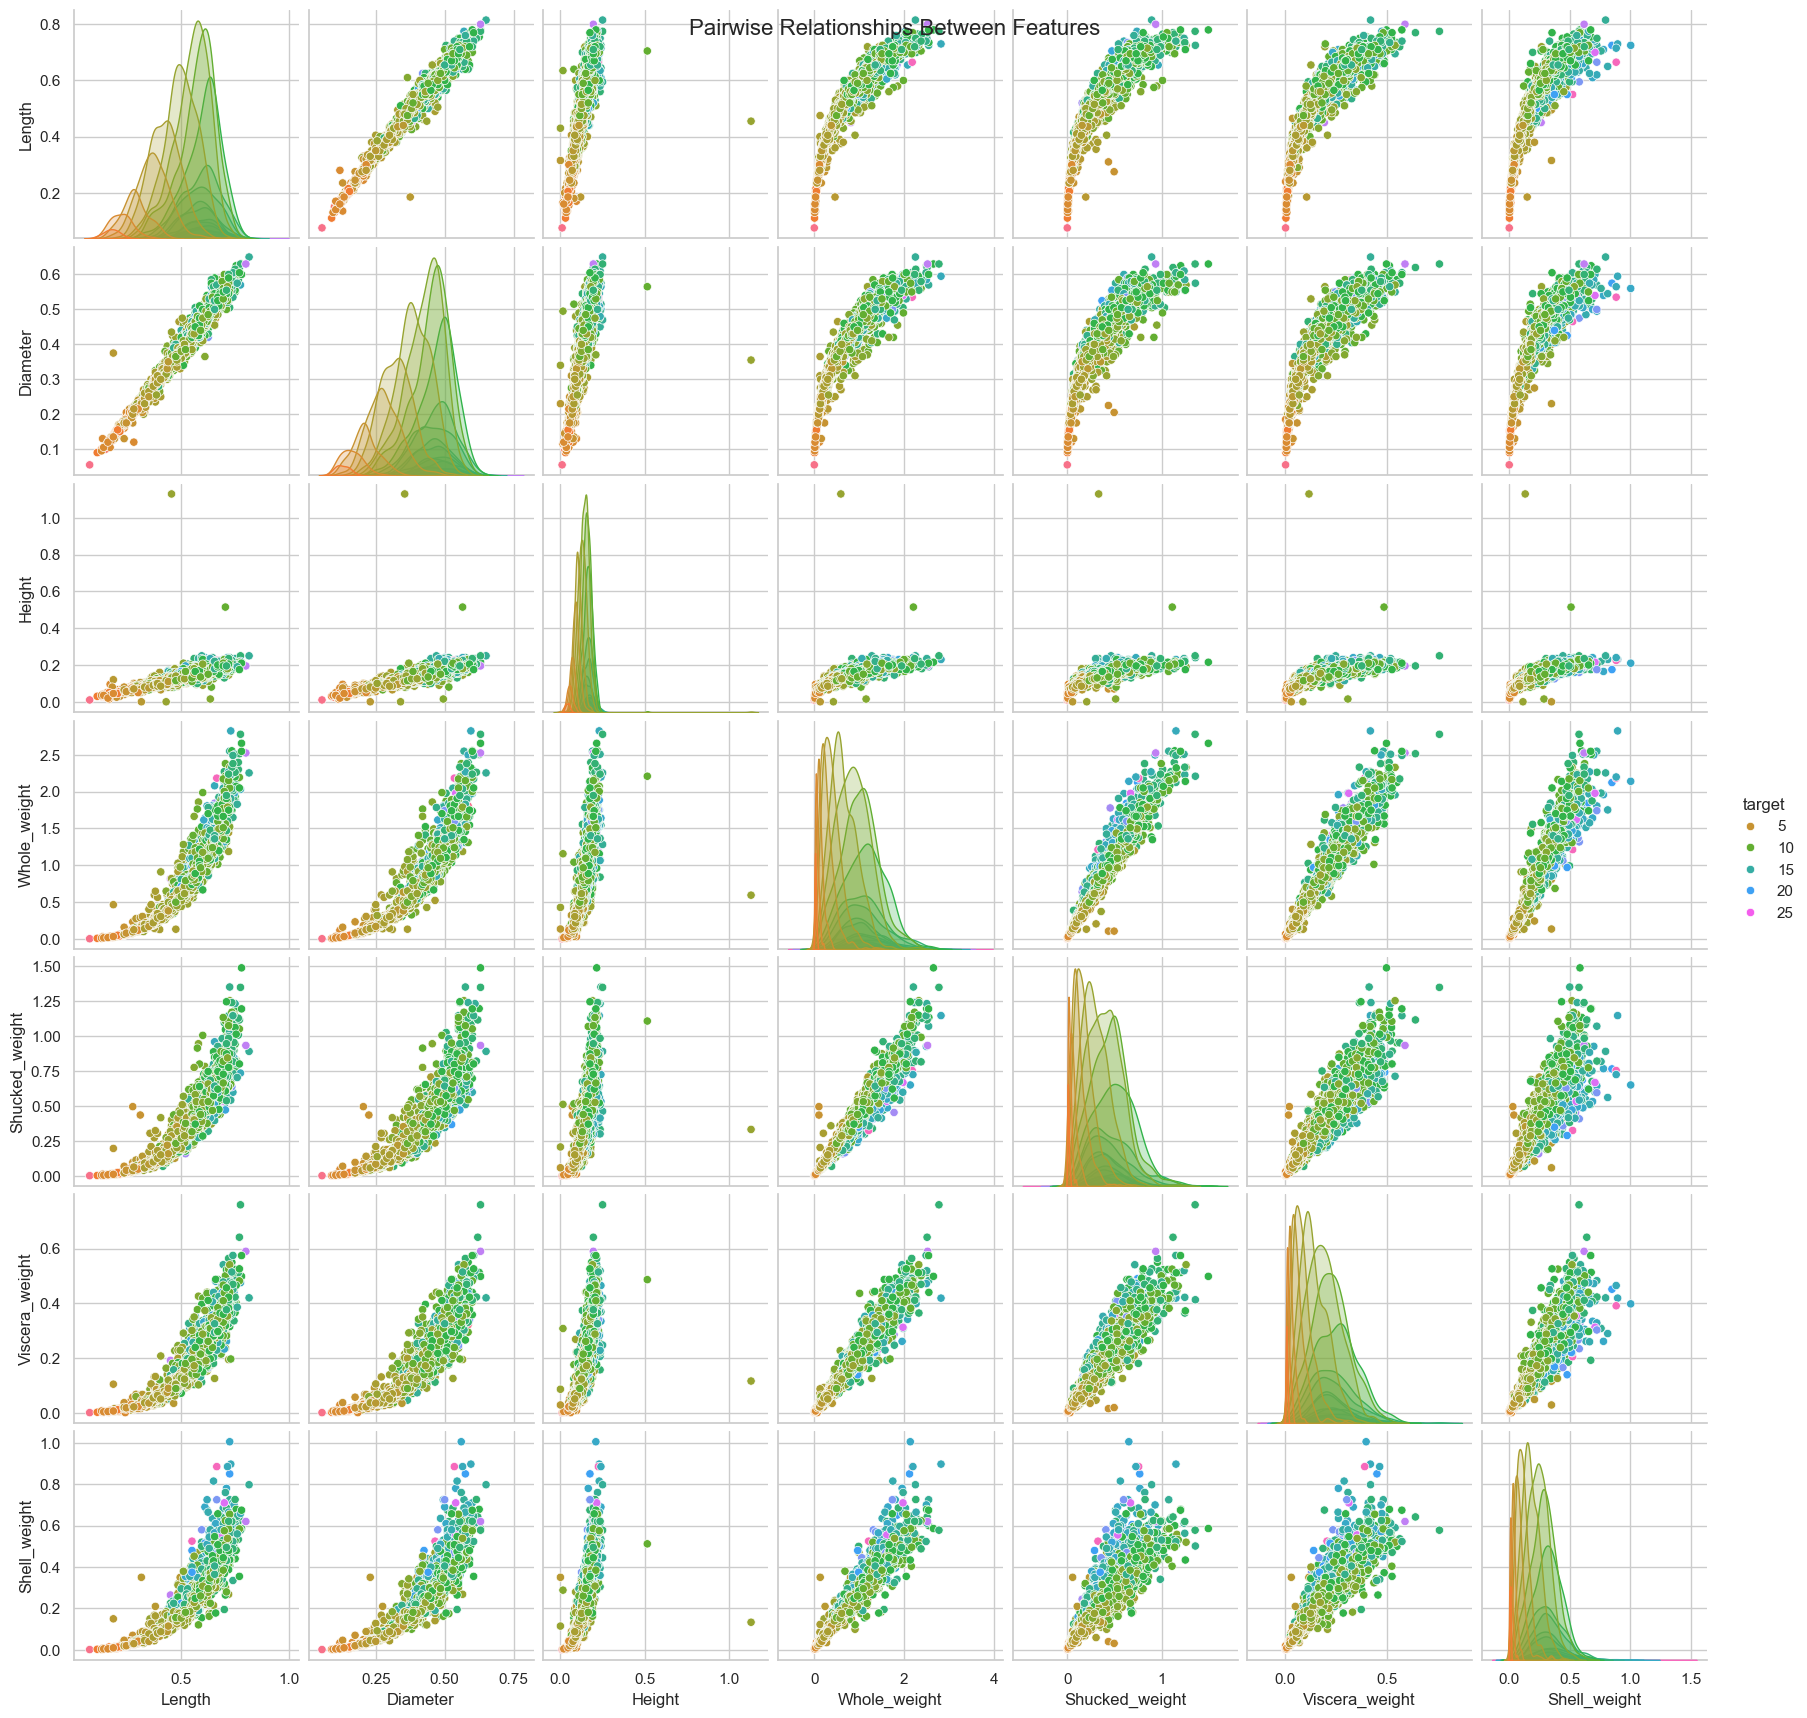

In [25]:
# Plot pairwise relationships between features using seaborn's pairplot
sns.pairplot(df, hue="target", palette="husl")
plt.suptitle("Pairwise Relationships Between Features", fontsize=16)

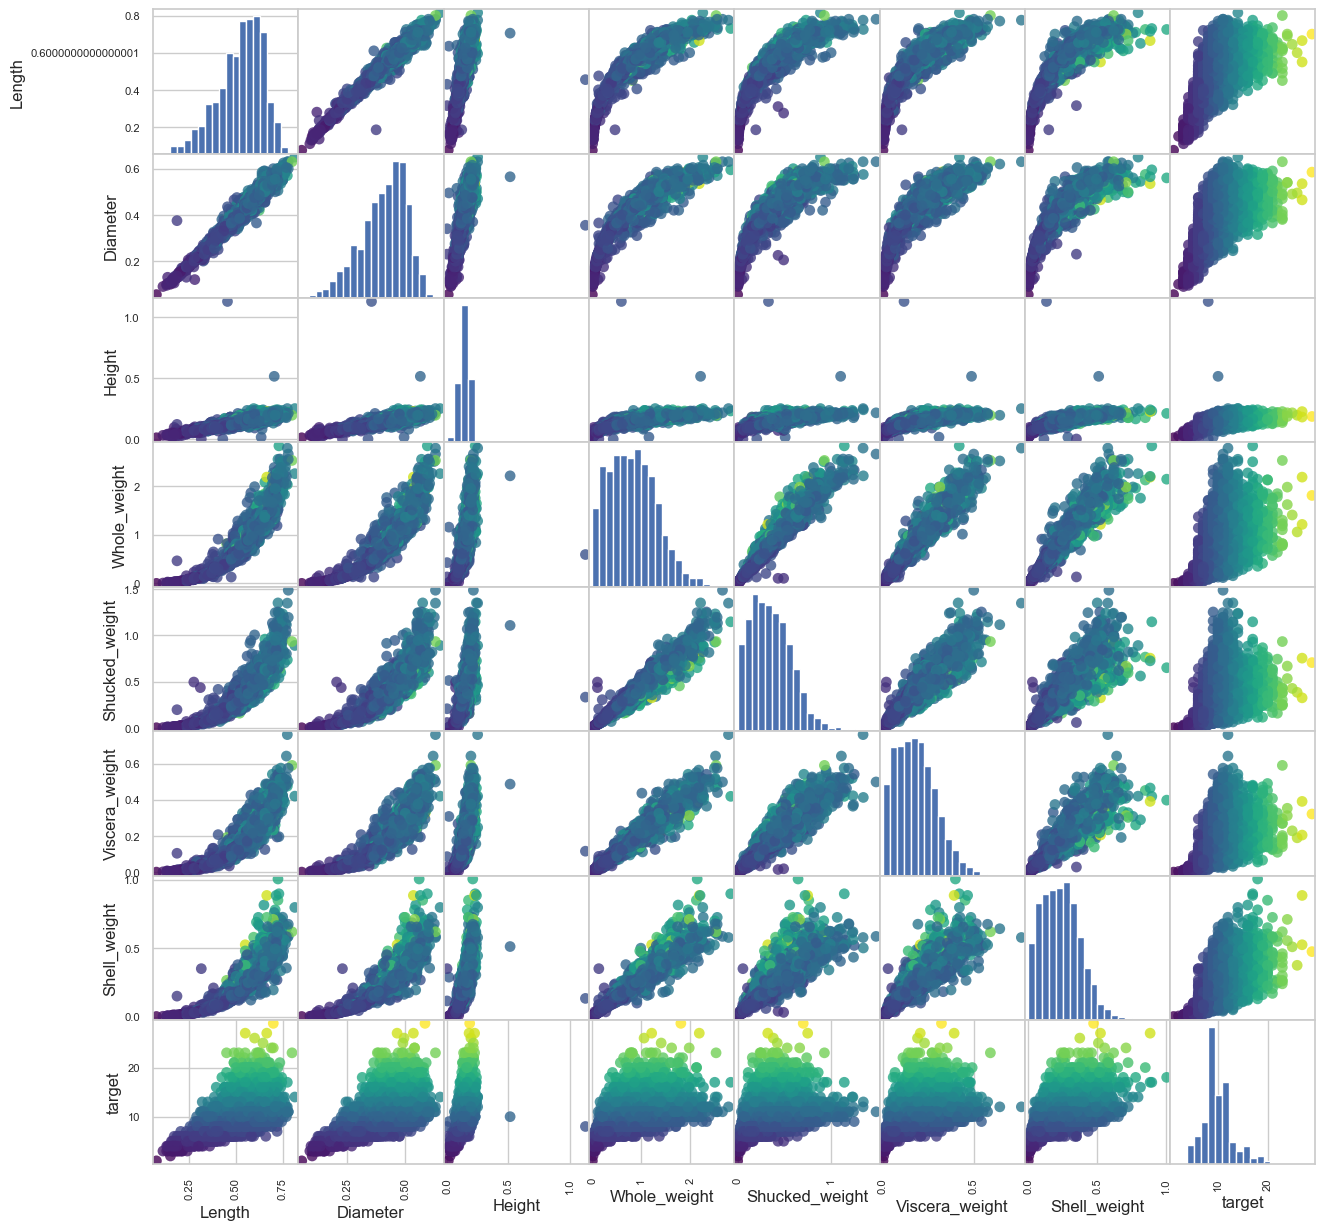

In [27]:
from pandas.plotting import scatter_matrix

grr = scatter_matrix(df, c=df["target"], figsize=(15, 15), marker='o',
    hist_kwds={'bins': 20}, s=60, alpha=.8, cmap='viridis')

<div class="alert alert-block alert-info">
<b>Questions:</b>

* Which species seems easiest to separate?
* Which features appear most informative?
</div>


This pairplot allows us to visualize the relationships between each pair of features, colored by the species. We can see how the different species are distributed in the feature space, which can help us understand the separability of the classes and guide our choice of classification algorithms.

#### Building Your First Model: k-Nearest Neighbors


In [30]:
# One-hot encode the 'Sex' column for both train and test sets
X_train_encoded = pd.get_dummies(X_train, columns=['Sex'])
X_test_encoded = pd.get_dummies(X_test, columns=['Sex'])

# Ensure both train and test have the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train_encoded, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None
